# 03 — EDA: Cancellation Analysis
**Hotel Booking Demand Dataset**

This notebook explores cancellation patterns in the cleaned dataset.
We examine the overall cancellation rate and compare behaviour across hotel types
to surface actionable business insights.

**Key questions:**
- What proportion of all bookings are cancelled?
- Does cancellation behaviour differ between City Hotels and Resort Hotels?
- What are the revenue and operational implications?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

PALETTE = {"Not Cancelled": "#2ca02c", "Cancelled": "#d62728",
           "City Hotel": "#1f77b4", "Resort Hotel": "#ff7f0e"}


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Hotels  : {df['hotel'].unique().tolist()}")
print(f"Nulls   : {df.isnull().sum().sum()}")


Dataset: 85,598 rows × 36 columns
Hotels  : ['Resort Hotel', 'City Hotel']
Nulls   : 0


---
## 1 — Overall Cancellation Rate

In [3]:
n_total      = len(df)
n_cancelled  = df["is_canceled"].sum()
n_active     = n_total - n_cancelled
cancel_rate  = df["is_canceled"].mean() * 100

print("=" * 45)
print(f"  Total bookings      : {n_total:>8,}")
print(f"  Cancelled           : {n_cancelled:>8,}  ({cancel_rate:.2f}%)")
print(f"  Not cancelled       : {n_active:>8,}  ({100 - cancel_rate:.2f}%)")
print("=" * 45)


  Total bookings      :   85,598
  Cancelled           :   23,839  (27.85%)
  Not cancelled       :   61,759  (72.15%)


### Pie Chart — Cancelled vs Not Cancelled

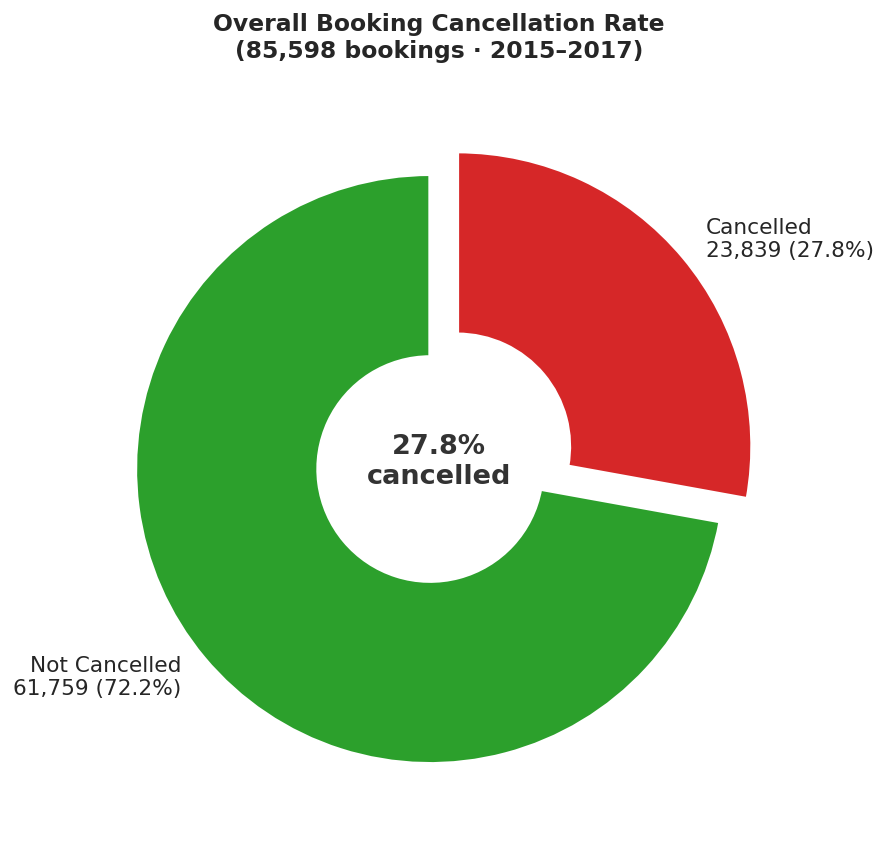

Saved → visuals/cancellation_overall_pie.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

sizes  = [n_active, n_cancelled]
labels = [f"Not Cancelled\n{n_active:,} ({100 - cancel_rate:.1f}%)",
          f"Cancelled\n{n_cancelled:,} ({cancel_rate:.1f}%)"]
colors  = [PALETTE["Not Cancelled"], PALETTE["Cancelled"]]
explode = (0.04, 0.08)

wedges, texts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    startangle=90,
    wedgeprops=dict(width=0.62, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12),
)

ax.set_title("Overall Booking Cancellation Rate\n(85,598 bookings · 2015–2017)",
             fontsize=13, fontweight="bold", pad=20)

# Centre annotation
ax.text(0, 0, f"{cancel_rate:.1f}%\ncancelled",
        ha="center", va="center", fontsize=15, fontweight="bold", color="#333333")

plt.tight_layout()
plt.savefig("../visuals/cancellation_overall_pie.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_overall_pie.png")


---
## 2 — Cancellation by Hotel Type

In [5]:
# Build summary table
hotel_stats = (
    df.groupby("hotel")["is_canceled"]
      .agg(
          Total="count",
          Cancelled="sum",
          Not_Cancelled=lambda x: (x == 0).sum(),
      )
      .assign(Cancellation_Rate=lambda d: (d["Cancelled"] / d["Total"] * 100).round(2))
      .sort_values("Cancellation_Rate", ascending=False)
)

print("Cancellation statistics by hotel type:")
print()
print(hotel_stats.to_string())


Cancellation statistics by hotel type:

              Total  Cancelled  Not_Cancelled  Cancellation_Rate
hotel                                                           
City Hotel    52351      15939          36412              30.45
Resort Hotel  33247       7900          25347              23.76


### Bar Chart — Cancellation Counts by Hotel Type

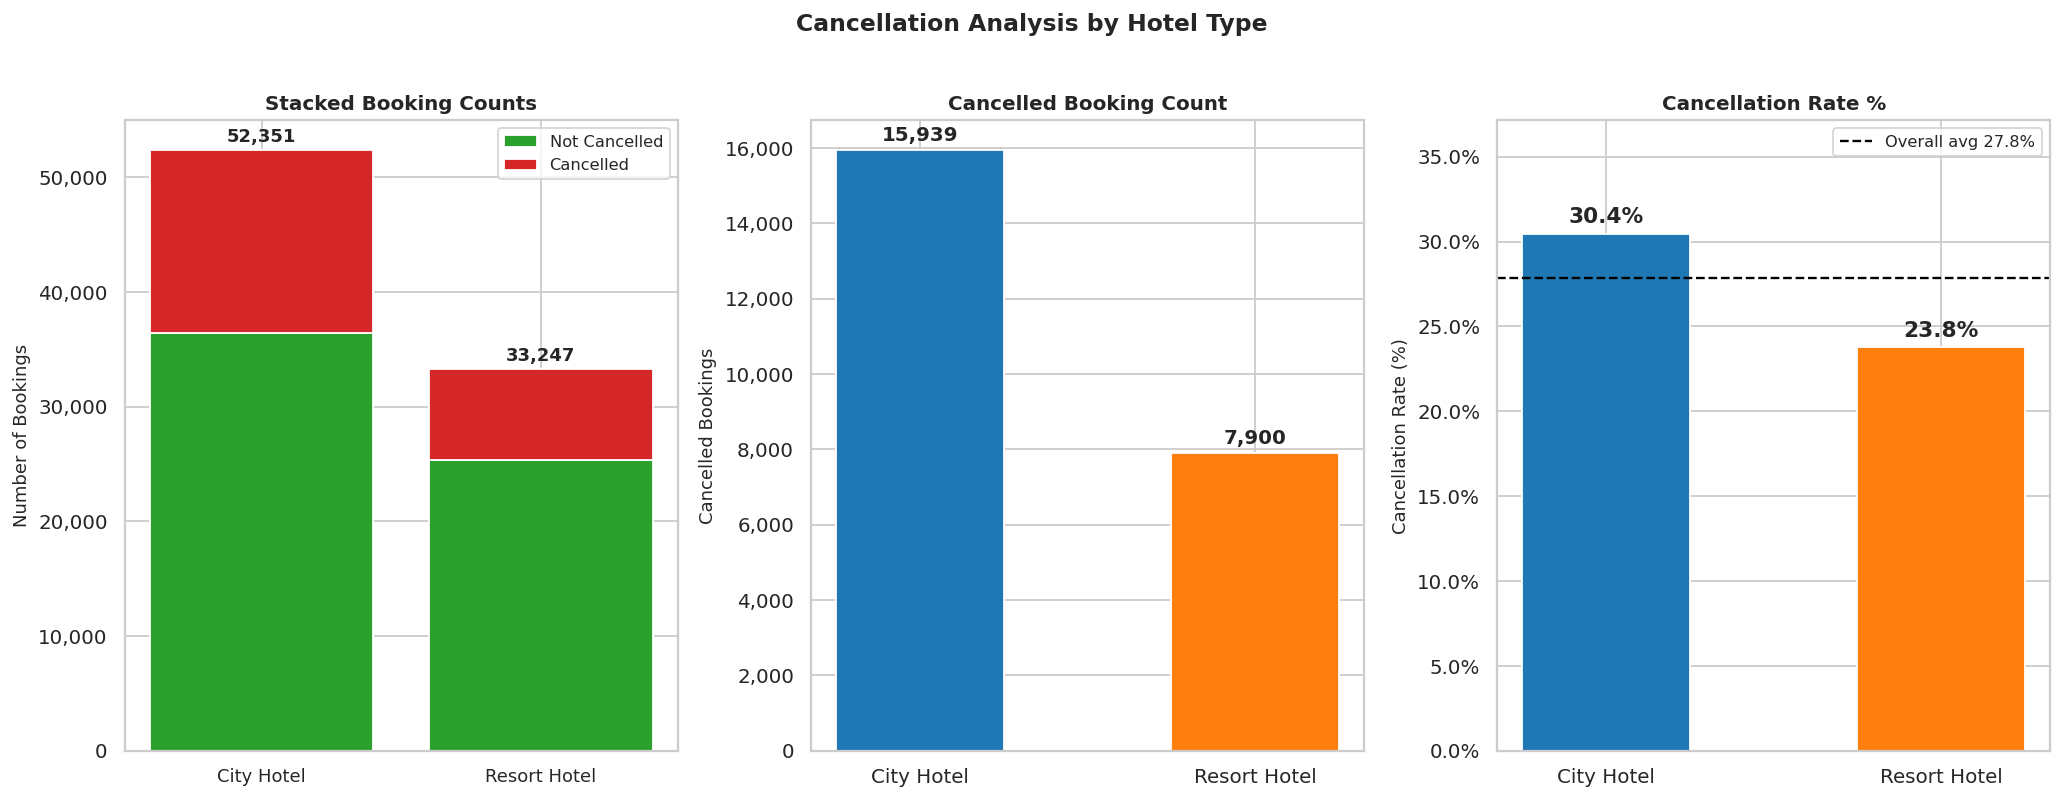

Saved → visuals/cancellation_by_hotel_type.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cancellation Analysis by Hotel Type",
             fontsize=13, fontweight="bold", y=1.02)

hotels     = hotel_stats.index.tolist()
bar_colors = [PALETTE.get(h, "#999") for h in hotels]

# ── Plot 1: Stacked absolute counts ─────────────────────────────────────────
x    = range(len(hotels))
bars_nc = axes[0].bar(x, hotel_stats["Not_Cancelled"],
                      color=[PALETTE["Not Cancelled"]] * len(hotels),
                      label="Not Cancelled", edgecolor="white")
bars_c  = axes[0].bar(x, hotel_stats["Cancelled"],
                      bottom=hotel_stats["Not_Cancelled"],
                      color=[PALETTE["Cancelled"]] * len(hotels),
                      label="Cancelled", edgecolor="white")

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(hotels, fontsize=10)
axes[0].set_ylabel("Number of Bookings", fontsize=10)
axes[0].set_title("Stacked Booking Counts", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].legend(fontsize=9)

# Annotate totals
for bar, total in zip(bars_c, hotel_stats["Total"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_y() + bar.get_height() + 400,
                 f"{total:,}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

# ── Plot 2: Cancelled count only (side-by-side) ───────────────────────────
bars2 = axes[1].bar(hotels, hotel_stats["Cancelled"],
                    color=bar_colors, edgecolor="white", width=0.5)
axes[1].set_ylabel("Cancelled Bookings", fontsize=10)
axes[1].set_title("Cancelled Booking Count", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 150,
                 f"{int(bar.get_height()):,}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

# ── Plot 3: Cancellation rate % ───────────────────────────────────────────
bars3 = axes[2].bar(hotels, hotel_stats["Cancellation_Rate"],
                    color=bar_colors, edgecolor="white", width=0.5)
axes[2].set_ylabel("Cancellation Rate (%)", fontsize=10)
axes[2].set_title("Cancellation Rate %", fontsize=11, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_ylim(0, hotel_stats["Cancellation_Rate"].max() * 1.22)

# Reference line: overall rate
axes[2].axhline(cancel_rate, color="black", linestyle="--",
                linewidth=1.3, label=f"Overall avg {cancel_rate:.1f}%")
axes[2].legend(fontsize=9)

for bar, rate in zip(bars3, hotel_stats["Cancellation_Rate"]):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f"{rate:.1f}%",
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/cancellation_by_hotel_type.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_by_hotel_type.png")


---
## 3 — Cancellation Rate per Hotel Type

In [7]:
print("Detailed breakdown by hotel type:")
print()

for hotel in hotels:
    subset = df[df["hotel"] == hotel]
    total  = len(subset)
    canc   = subset["is_canceled"].sum()
    rate   = canc / total * 100
    print(f"  {hotel}")
    print(f"    Total bookings      : {total:,}")
    print(f"    Cancelled           : {canc:,}  ({rate:.2f}%)")
    print(f"    Not cancelled       : {total - canc:,}  ({100 - rate:.2f}%)")
    print(f"    vs overall avg      : {rate - cancel_rate:+.2f} pp")
    print()


Detailed breakdown by hotel type:

  City Hotel
    Total bookings      : 52,351
    Cancelled           : 15,939  (30.45%)
    Not cancelled       : 36,412  (69.55%)
    vs overall avg      : +2.60 pp

  Resort Hotel
    Total bookings      : 33,247
    Cancelled           : 7,900  (23.76%)
    Not cancelled       : 25,347  (76.24%)
    vs overall avg      : -4.09 pp



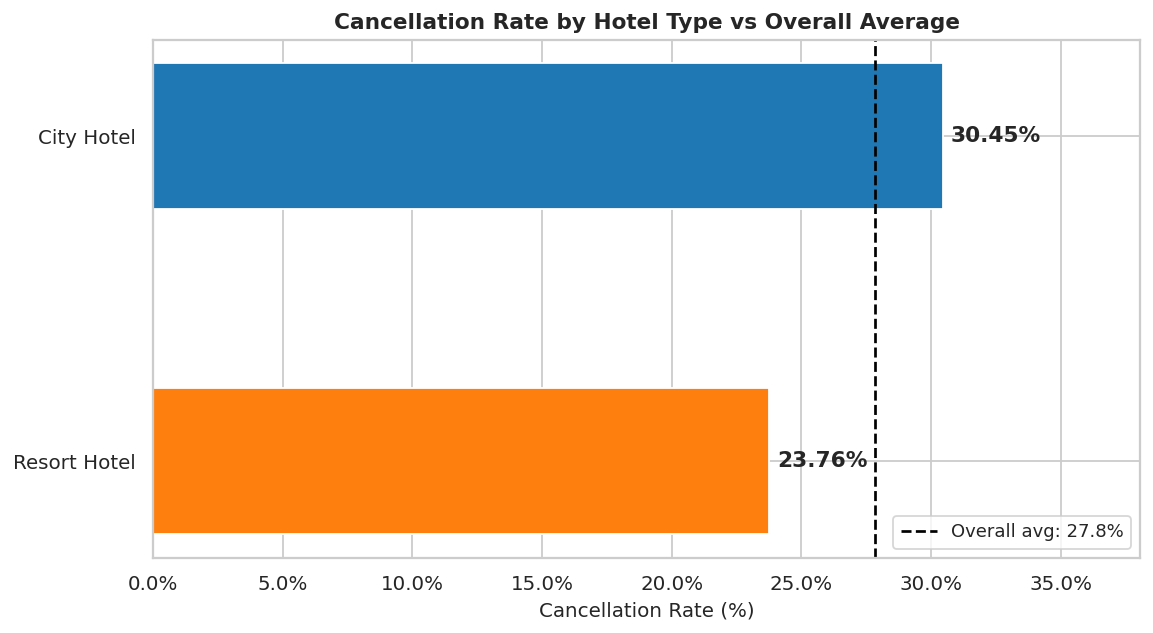

Saved → visuals/cancellation_rate_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

rate_data = hotel_stats["Cancellation_Rate"].reset_index()
bars = ax.barh(rate_data["hotel"], rate_data["Cancellation_Rate"],
               color=bar_colors, edgecolor="white", height=0.45)

ax.axvline(cancel_rate, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall avg: {cancel_rate:.1f}%")

for bar, rate in zip(bars, rate_data["Cancellation_Rate"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.2f}%", va="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Cancellation Rate (%)", fontsize=11)
ax.set_title("Cancellation Rate by Hotel Type vs Overall Average",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(rate_data["Cancellation_Rate"]) * 1.25)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../visuals/cancellation_rate_comparison.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_rate_comparison.png")


---
## 4 — Key Findings & Business Implications

### 4.1 Overall Cancellation Rate

The overall cancellation rate across both hotels is **27.85%** — meaning more than
1 in 4 bookings is cancelled before arrival. With 23,839 cancellations out of 85,598
bookings, this represents a substantial and recurring revenue risk for both properties.

---

### 4.2 Which Hotel Type Has Higher Cancellations?

| Hotel Type | Total Bookings | Cancelled | Cancellation Rate | vs Overall |
|------------|---------------|-----------|------------------|------------|
| **City Hotel** | 52,351 | 15,939 | **30.45%** | +2.60 pp |
| Resort Hotel | 33,247 | 7,900 | **23.76%** | −4.09 pp |

**City Hotel has a significantly higher cancellation rate at 30.45%**, compared to
23.76% for Resort Hotel — a gap of **6.69 percentage points**.

City Hotel also handles a far larger volume of bookings (52,351 vs 33,247), meaning
the absolute number of cancellations is more than double that of Resort Hotel
(15,939 vs 7,900).

---

### 4.3 Why Does City Hotel Cancel More?

Several structural factors likely drive this disparity:

**1. Booking intent & flexibility**
City Hotel guests are more likely to be business travellers or short-break tourists
who book opportunistically and change plans more readily. Resort Hotel guests typically
plan holidays months in advance with stronger commitment to travel.

**2. Lead time & advance bookings**
City Hotel bookings tend to have shorter lead times but also higher last-minute
cancellations. Guests may book multiple city hotels and cancel after confirming
alternatives — a pattern less common for resort stays.

**3. OTA dependency**
City Hotels are more heavily distributed through Online Travel Agents (OTAs like
Booking.com, Expedia), which offer free or flexible cancellation policies as a
competitive differentiator, structurally increasing cancellation risk.

**4. Length of stay**
Resort bookings typically involve longer stays (higher sunk cost of planning),
creating a natural deterrent to cancellation. City stays are often 1–2 nights,
where re-booking friction is low.

---

### 4.4 Business Implications

#### For City Hotel (30.45% cancellation rate) 🔴 High Priority
- **Overbooking strategy:** At a 30% cancellation rate, maintaining a calibrated
  overbooking buffer of 8–12% can recover significant revenue without risking
  too many walk-ins.
- **Deposit policy:** Introduce non-refundable or partially refundable rates for
  high-lead-time bookings to incentivise commitment.
- **Cancellation prediction model:** City Hotel data should be the primary focus
  for the ML model in Week 3 — the signal is stronger and the revenue impact larger.
- **Last-minute promotions:** Use predicted cancellation slots to launch dynamic
  discount campaigns 24–48 hours before arrival.

#### For Resort Hotel (23.76% cancellation rate) 🟡 Moderate
- **Lower urgency** but still meaningful — 1 in 4 resort bookings cancels.
- **Seasonal exposure:** Resort cancellations likely spike during peak summer
  season (July–August). A targeted retention campaign before high-season
  cut-off dates could recover high-value long-stay bookings.
- **Package incentives:** Offer F&B or activity bundles for guests who confirm
  non-refundable rates, converting flexible to committed bookings.

#### Shared priority
- **Revenue at risk (estimate):** With a mean `revenue_per_booking` of ~£403 and
  23,839 cancellations, the theoretical revenue exposure is approximately
  **£9.6 million** across the dataset period — though not all would have been
  recoverable.
- A **1 percentage point reduction** in cancellation rate would retain ~856 bookings
  ≈ **£345,000** in potential revenue.

---

> **Next analysis:** `04_eda_pricing.ipynb` — ADR trends, seasonality, and pricing
> patterns by hotel type, market segment, and arrival month.


---
# Part 2 — Lead Time Analysis vs Cancellation

**Lead time** = number of days between the booking date and the scheduled arrival date.

Key questions:
- Do guests who book far in advance cancel more often?
- At what lead-time threshold does cancellation risk accelerate?
- How should hotels adjust their overbooking strategy accordingly?


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

PALETTE = {0: "#2ca02c", 1: "#d62728"}
BUCKET_COLORS = ["#4daf4a", "#ff7f00", "#e41a1c", "#984ea3"]

df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

cancel_map = {0: "Not Cancelled", 1: "Cancelled"}
df["cancellation_label"] = df["is_canceled"].map(cancel_map)

print(f"Loaded: {df.shape[0]:,} rows  |  lead_time range: "
      f"{df['lead_time'].min()} – {df['lead_time'].max()} days")


Loaded: 85,598 rows  |  lead_time range: 0 – 709 days


---
## 1 — Average Lead Time: Cancelled vs Not Cancelled

In [10]:
lead_stats = df.groupby("is_canceled")["lead_time"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std",
    P25=lambda x: x.quantile(0.25),
    P75=lambda x: x.quantile(0.75),
    Max="max",
).round(1)
lead_stats.index = ["Not Cancelled (0)", "Cancelled (1)"]

print("Lead time statistics by cancellation status:")
print()
print(lead_stats.to_string())
print()

avg_nc = df[df["is_canceled"]==0]["lead_time"].mean()
avg_c  = df[df["is_canceled"]==1]["lead_time"].mean()
print(f"  ➤ Cancelled bookings have a lead time {avg_c - avg_nc:.1f} days "
      f"longer on average ({avg_nc:.1f} vs {avg_c:.1f} days)")


Lead time statistics by cancellation status:

                   Count   Mean  Median   Std   P25    P75  Max
Not Cancelled (0)  61759   71.0    39.0  81.6   7.0  112.0  709
Cancelled (1)      23839  106.0    80.0  91.6  33.0  159.0  629

  ➤ Cancelled bookings have a lead time 35.0 days longer on average (71.0 vs 106.0 days)


---
## 2 — Lead Time Distribution: Cancelled vs Not Cancelled

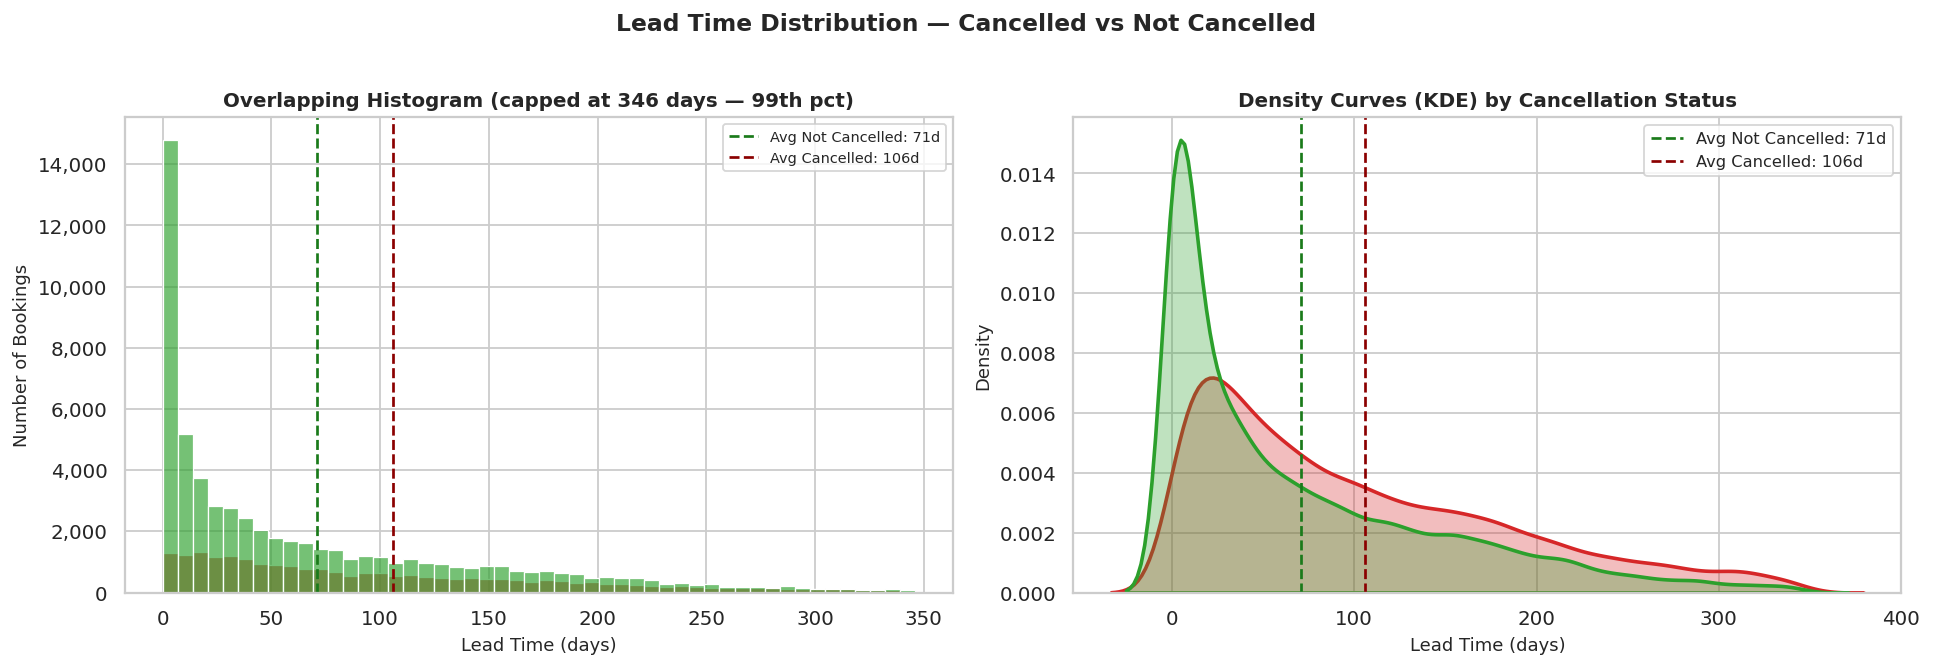

Saved → visuals/lead_time_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Lead Time Distribution — Cancelled vs Not Cancelled",
             fontsize=13, fontweight="bold", y=1.02)

# Cap at 99th percentile for readable axes (709-day max is an extreme outlier)
cap = int(df["lead_time"].quantile(0.99))
df_plot = df[df["lead_time"] <= cap].copy()

# ── Plot 1: Overlapping histplot ─────────────────────────────────────────────
sns.histplot(
    data=df_plot, x="lead_time", hue="cancellation_label",
    bins=50, ax=axes[0], alpha=0.65, edgecolor="white",
    palette={"Not Cancelled": "#2ca02c", "Cancelled": "#d62728"},
    hue_order=["Not Cancelled", "Cancelled"],
)
axes[0].set_title(f"Overlapping Histogram (capped at {cap} days — 99th pct)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Lead Time (days)", fontsize=10)
axes[0].set_ylabel("Number of Bookings", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Median lines
for val, label, color in [(avg_nc, f"Avg Not Cancelled: {avg_nc:.0f}d", "#1a7a1a"),
                           (avg_c,  f"Avg Cancelled: {avg_c:.0f}d",    "#8b0000")]:
    axes[0].axvline(val, linestyle="--", linewidth=1.5, color=color, label=label)
axes[0].legend(fontsize=8)

# ── Plot 2: KDE curves ───────────────────────────────────────────────────────
sns.kdeplot(
    data=df_plot, x="lead_time", hue="cancellation_label",
    ax=axes[1], fill=True, alpha=0.3, linewidth=2,
    palette={"Not Cancelled": "#2ca02c", "Cancelled": "#d62728"},
    hue_order=["Not Cancelled", "Cancelled"],
    common_norm=False,
)
axes[1].set_title("Density Curves (KDE) by Cancellation Status",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Lead Time (days)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)

# Shade the gap region showing cancellations skew right
axes[1].axvline(avg_nc, linestyle="--", linewidth=1.5, color="#1a7a1a",
                label=f"Avg Not Cancelled: {avg_nc:.0f}d")
axes[1].axvline(avg_c,  linestyle="--", linewidth=1.5, color="#8b0000",
                label=f"Avg Cancelled: {avg_c:.0f}d")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/lead_time_distribution.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/lead_time_distribution.png")


---
## 3 — Lead Time Buckets & Cancellation Rate per Bucket

In [12]:
bins   = [0, 30, 90, 180, df["lead_time"].max() + 1]
labels = ["0–30 days", "31–90 days", "91–180 days", "180+ days"]

df["lead_time_bucket"] = pd.cut(
    df["lead_time"], bins=bins, labels=labels,
    right=True, include_lowest=True
)

bucket_stats = (
    df.groupby("lead_time_bucket", observed=True)["is_canceled"]
      .agg(Total="count", Cancelled="sum")
      .assign(
          Not_Cancelled=lambda x: x["Total"] - x["Cancelled"],
          Cancel_Rate_pct=lambda x: (x["Cancelled"] / x["Total"] * 100).round(2),
      )
)

print("Cancellation stats by lead time bucket:")
print()
print(bucket_stats.to_string())


Cancellation stats by lead time bucket:

                  Total  Cancelled  Not_Cancelled  Cancel_Rate_pct
lead_time_bucket                                                  
0–30 days         33319       5571          27748            16.72
31–90 days        22517       7253          15264            32.21
91–180 days       18127       6367          11760            35.12
180+ days         11635       4648           6987            39.95


### Bar Chart — Cancellation Rate per Lead Time Bucket

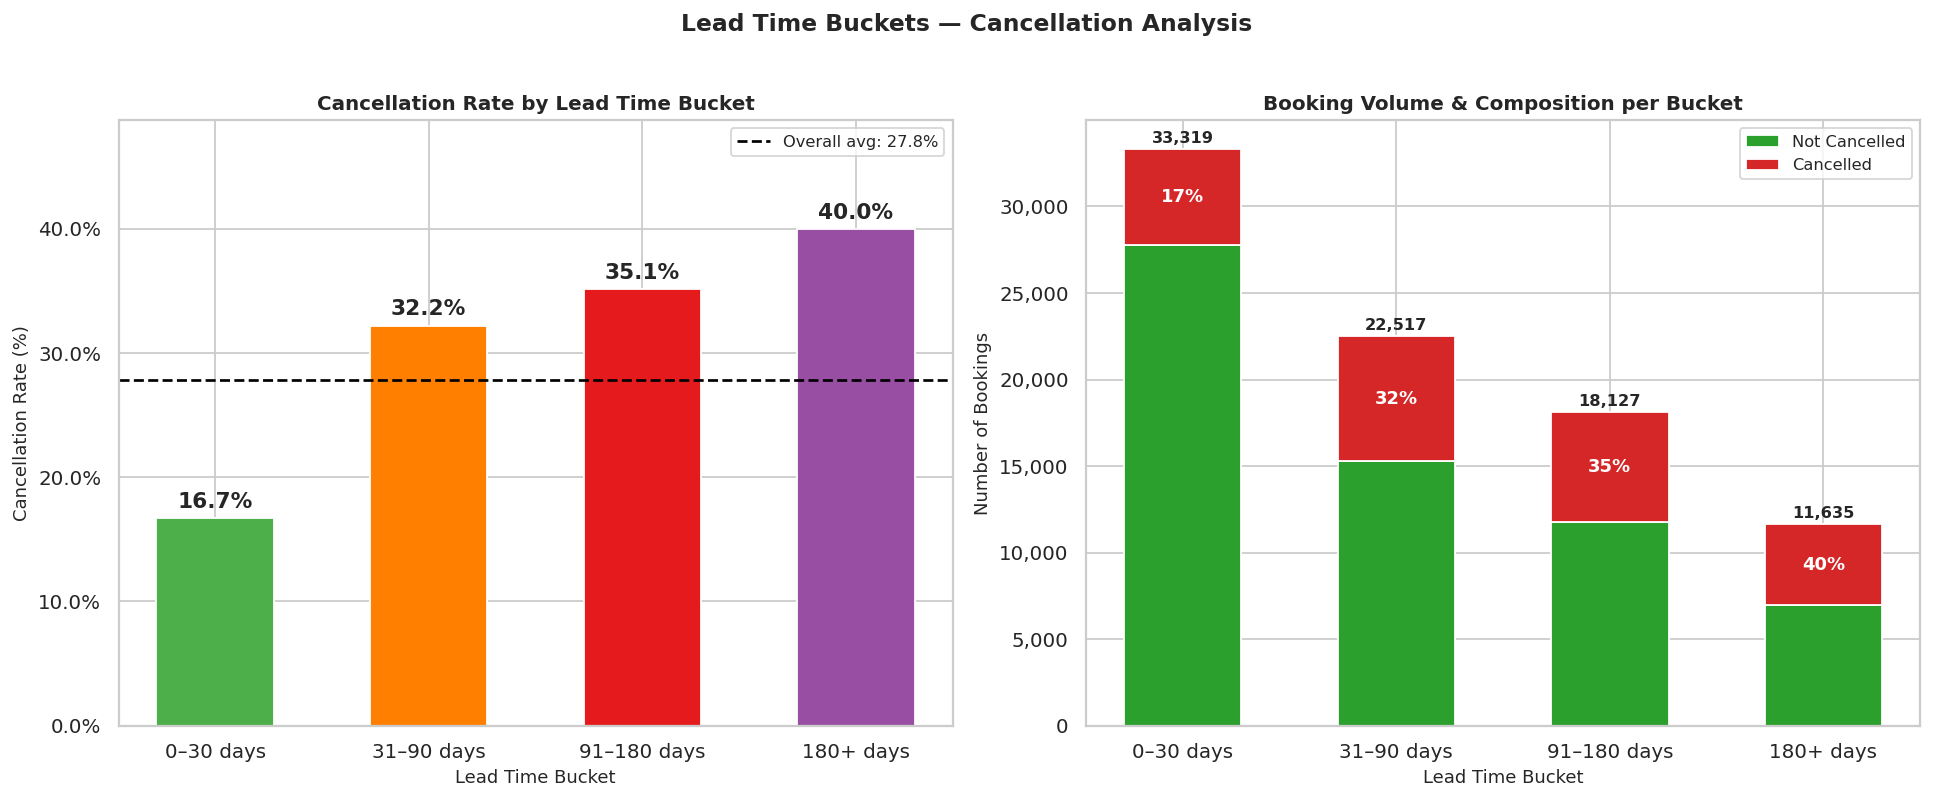

Saved → visuals/lead_time_bucket_cancellation.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Lead Time Buckets — Cancellation Analysis",
             fontsize=13, fontweight="bold", y=1.02)

buckets = bucket_stats.index.tolist()
rates   = bucket_stats["Cancel_Rate_pct"].values
totals  = bucket_stats["Total"].values

# ── Plot 1: Cancellation rate per bucket ─────────────────────────────────────
bars1 = axes[0].bar(buckets, rates, color=BUCKET_COLORS,
                    edgecolor="white", width=0.55)
axes[0].axhline(df["is_canceled"].mean() * 100, color="black",
                linestyle="--", linewidth=1.5,
                label=f"Overall avg: {df['is_canceled'].mean()*100:.1f}%")

for bar, rate in zip(bars1, rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{rate:.1f}%", ha="center", va="bottom",
                 fontsize=12, fontweight="bold")

axes[0].set_title("Cancellation Rate by Lead Time Bucket",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Lead Time Bucket", fontsize=10)
axes[0].set_ylabel("Cancellation Rate (%)", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(rates) * 1.22)
axes[0].legend(fontsize=9)

# ── Plot 2: Stacked count per bucket ─────────────────────────────────────────
nc_counts = bucket_stats["Not_Cancelled"].values
c_counts  = bucket_stats["Cancelled"].values

axes[1].bar(buckets, nc_counts, color="#2ca02c",
            edgecolor="white", width=0.55, label="Not Cancelled")
axes[1].bar(buckets, c_counts, bottom=nc_counts,
            color="#d62728", edgecolor="white", width=0.55, label="Cancelled")

for i, (nc, c, tot) in enumerate(zip(nc_counts, c_counts, totals)):
    axes[1].text(i, tot + 180, f"{tot:,}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
    # Rate label inside the cancelled portion
    axes[1].text(i, nc + c / 2,
                 f"{c/tot*100:.0f}%",
                 ha="center", va="center", fontsize=10,
                 fontweight="bold", color="white")

axes[1].set_title("Booking Volume & Composition per Bucket",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Lead Time Bucket", fontsize=10)
axes[1].set_ylabel("Number of Bookings", fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/lead_time_bucket_cancellation.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/lead_time_bucket_cancellation.png")


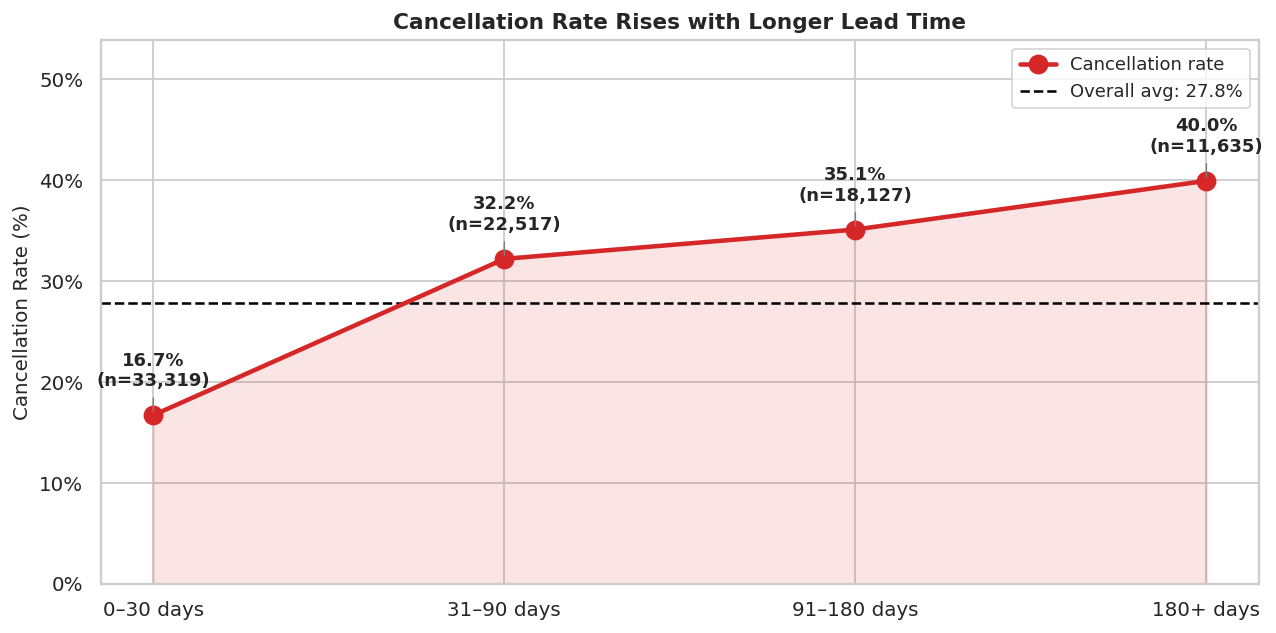

Saved → visuals/lead_time_cancellation_trend.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(buckets))
ax.plot(list(x_pos), rates, marker="o", markersize=10,
        linewidth=2.5, color="#d62728", zorder=3, label="Cancellation rate")
ax.fill_between(list(x_pos), rates, alpha=0.12, color="#d62728")

for xi, (bucket, rate, total) in enumerate(zip(buckets, rates, totals)):
    ax.annotate(
        f"{rate:.1f}%\n(n={total:,})",
        xy=(xi, rate),
        xytext=(0, 16), textcoords="offset points",
        ha="center", fontsize=10, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    )

ax.axhline(df["is_canceled"].mean() * 100, color="black",
           linestyle="--", linewidth=1.4,
           label=f"Overall avg: {df['is_canceled'].mean()*100:.1f}%")

ax.set_xticks(list(x_pos))
ax.set_xticklabels(buckets, fontsize=11)
ax.set_ylabel("Cancellation Rate (%)", fontsize=11)
ax.set_title("Cancellation Rate Rises with Longer Lead Time",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(rates) * 1.35)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/lead_time_cancellation_trend.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/lead_time_cancellation_trend.png")


---
## 4 — Key Insights: Lead Time vs Cancellation Risk

### 4.1 Does Longer Lead Time = Higher Cancellation Risk?

**Yes — clearly and consistently.**

| Lead Time Bucket | Total Bookings | Cancelled | Cancellation Rate |
|-----------------|---------------|-----------|------------------|
| 0–30 days | 33,319 | 5,571 | **16.72%** |
| 31–90 days | 22,517 | 7,253 | **32.21%** |
| 91–180 days | 18,127 | 6,367 | **35.12%** |
| 180+ days | 11,635 | 4,648 | **39.95%** |
| **Overall** | **85,598** | **23,839** | **27.85%** |

The cancellation rate climbs from **16.7%** for last-minute bookings (0–30 days) to
**40.0%** for bookings made more than 6 months ahead — a **2.4× increase in risk**
across the spectrum.

**Key numbers:**
- Cancelled bookings have a mean lead time of **106 days** vs **71 days** for
  non-cancelled bookings — a **35-day gap**.
- The median gap is even more striking: **80 days** (cancelled) vs **39 days**
  (not cancelled) — cancelled guests book roughly **twice as far in advance**.
- The KDE curves show the cancelled distribution is right-skewed, with a heavy
  tail above 150 days — a population of highly advance, high-risk bookings.

---

### 4.2 Why Does This Pattern Exist?

**1. Plans change over long horizons**
A guest booking 6 months ahead is committing under maximum uncertainty. Travel
plans, work schedules, and budgets are far more volatile over 6 months than over
2 weeks.

**2. Free cancellation arbitrage**
OTAs commonly allow free cancellation on advance bookings. Guests routinely book
early at a good price, then cancel if a better deal or a change of plans emerges —
a deliberate hedging strategy enabled by no-cost cancellation policies.

**3. Lower psychological commitment**
A booking 200 days out feels abstract. The closer arrival approaches, the stronger
the sunk-cost and commitment effect. Last-minute bookers have already made the
mental decision to travel.

**4. Corporate / group bookings**
Long lead-time bookings are disproportionately corporate or group bookings, which
are frequently modified or cancelled as conference plans, headcounts, or budgets shift.

---

### 4.3 Implications for Overbooking Strategy

The lead-time bucket breakdown allows hotels to apply a **tiered overbooking policy**
rather than a flat-rate buffer:

| Lead Time at Booking | Cancellation Risk | Recommended Overbooking Buffer |
|---------------------|------------------|-------------------------------|
| 0–30 days | Low (16.7%) | ~5–8% — minimal buffer needed |
| 31–90 days | Moderate (32.2%) | ~12–15% — standard buffer |
| 91–180 days | High (35.1%) | ~18–22% — elevated buffer |
| 180+ days | Very high (39.9%) | ~25–30% — aggressive buffer or non-refundable policy |

**Strategic recommendations:**

- **Dynamic non-refundable pricing:** Offer a meaningful discount (10–15%) on
  non-refundable rates specifically for bookings >90 days out — the highest-risk
  segment. Converts a high-risk flexible booking into a guaranteed revenue booking.

- **Reminder / re-confirmation campaigns:** Send a re-confirmation prompt ~60 and
  ~30 days before arrival for bookings made 90+ days ahead. Proactive engagement
  reduces silent cancellations and surfaces intent early enough to re-sell the room.

- **Overbooking ramp schedule:** Instead of a flat overbooking percentage, apply
  a rolling adjustment: as lead time shrinks, the overbooking allowance should
  automatically contract (since last-minute cancellations are less common and
  walk-in rebooking is harder to arrange).

- **ML model priority feature:** `lead_time` is likely to be one of the strongest
  individual predictors in the cancellation model (Week 3). The bucket structure
  suggests a non-linear relationship — a tree-based model or a binned feature
  will capture the threshold effects between brackets better than raw lead time alone.

---

> **Next:** Lead time interacts with deposit type, market segment, and booking channel.
> These multi-factor interactions will be explored in `04_eda_pricing.ipynb`.
